# Geometric Analysis

In this notebook, we loaded our JSON responses file and our hidden state numpy zipped file produced as the results from the inference notebook. In order to run this notebook, `results/responses.jsonl` and `results/hidden_states.npz` should be downloaded to run successfully.


## Imports

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from google.colab import drive
drive.mount('/content/drive')
drive_path = Path("/content/drive/My Drive/triage")
results_dir = drive_path / "results"

# set conditions
conditions  = ["zero_shot", "system_safety","few_shot", "chain_of_thought"]

# set colors for conditions
condition_colors = {
    "zero_shot":        "#4C72B0",
    "system_safety":    "#DD8452",
    "few_shot":         "#55A868",
    "chain_of_thought": "#C44E52",
}

# set colors for outcomes
outcome_colors = {
    "correct":    "#55A868",
    "undertriage": "#C44E52",
    "overtriage":  "#4C72B0",
    "unparsed":    "#808080",
}

Mounted at /content/drive


## Data loading, validation, and feature matrix

In [2]:
df = pd.DataFrame(
    [json.loads(line) for line in open(results_dir / "responses.jsonl")]
)
print(f"Number of responses: {len(df)} rows")
print(df["outcome"].value_counts())

# hidden states are keyed as "CH9_001__zero_shot"
# this checks if the number of entries and shape matches
hs = np.load(results_dir / "hidden_states.npz", allow_pickle=False)
print(f"\nHidden states: {len(hs.files)} entries")
print(f"Shape for each entry: {hs[hs.files[0]].shape}") # We expect (4, 4096)

Number of responses: 600 rows
outcome
correct        247
overtriage     189
undertriage    157
unparsed         7
Name: count, dtype: int64

Hidden states: 600 entries
Shape for each entry: (4, 4096)


In [3]:
# build X aligned to df row order
# Each row in X is the hidden state for one vignette times condition pair.
# only the last transformer layer is used because
# it's the most task-relevant and simplest to interpret.
X_raw = np.stack([
    hs[f"{row.vignette_id}__{row.condition}"][-1]
    for _, row in df.iterrows()
])

# standardize before PCA and probes
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"X shape: {X.shape}")

X shape: (600, 4096)


## PCA

PCA explained variance: PC1=43.6%  PC2=25.3%


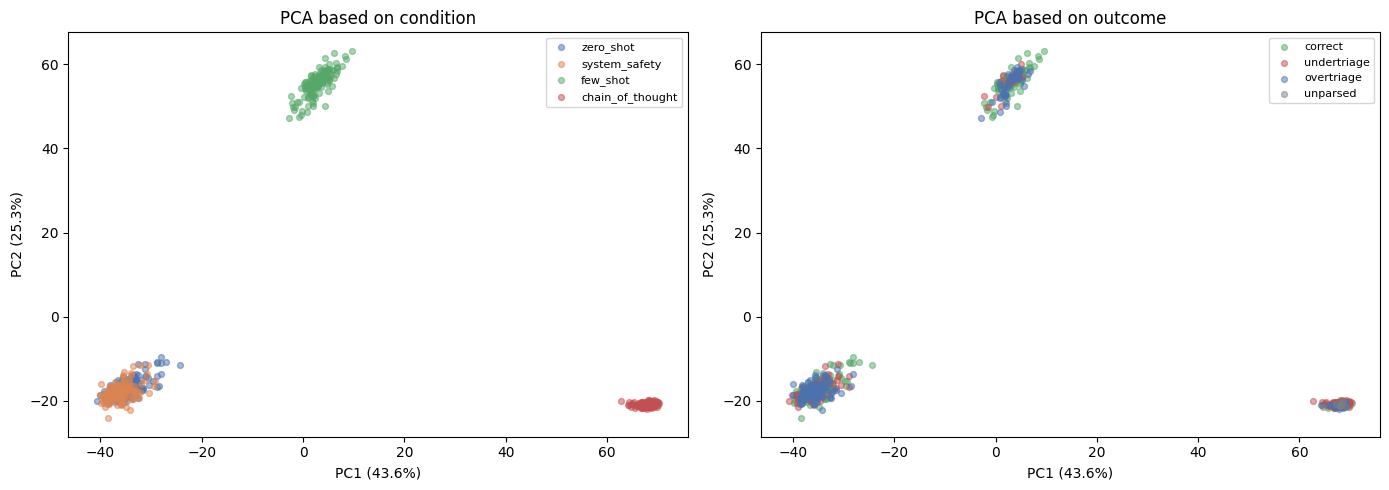

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# condition-based coloring
ax = axes[0]
for cond in conditions:
    mask = df["condition"] == cond
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=condition_colors[cond], label=cond, alpha=0.5, s=18)
ax.set_title("PCA based on condition")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(fontsize=8)

# outcome-based coloring
ax = axes[1]
for outcome in ["correct", "undertriage", "overtriage", "unparsed"]:
    mask = df["outcome"] == outcome
    if mask.sum() == 0:
        continue
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=outcome_colors[outcome], label=outcome, alpha=0.5, s=18)
ax.set_title("PCA based on outcome")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(fontsize=8)

# Display and save outputs
plt.tight_layout()
plt.savefig(results_dir / "pca.png", dpi=150)
plt.show()

## t-SNE

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


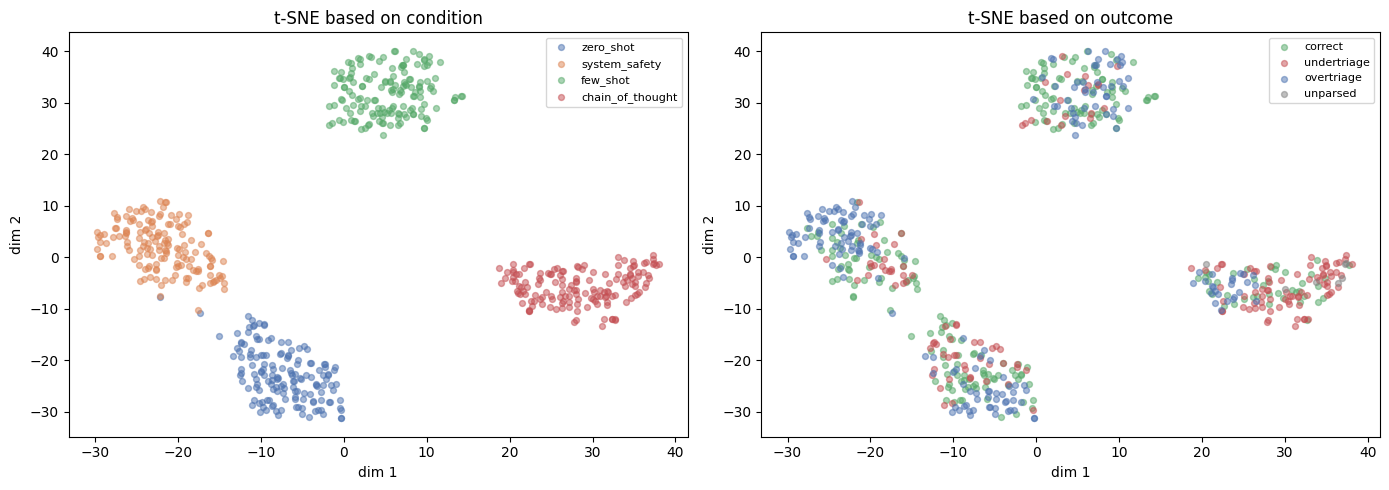

In [5]:
# run t-SNE on PCA-reduced space (50 dims) for speed
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# condition-based coloring
ax = axes[0]
for cond in conditions:
    mask = df["condition"] == cond
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=condition_colors[cond], label=cond, alpha=0.5, s=18)
ax.set_title("t-SNE based on condition")
ax.set_xlabel("dim 1")
ax.set_ylabel("dim 2")
ax.legend(fontsize=8)

# outcome-based coloring
ax = axes[1]
for outcome in ["correct", "undertriage", "overtriage", "unparsed"]:
    mask = df["outcome"] == outcome
    if mask.sum() == 0:
        continue
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=outcome_colors[outcome], label=outcome, alpha=0.5, s=18)
ax.set_title("t-SNE based on outcome")
ax.set_xlabel("dim 1")
ax.set_ylabel("dim 2")
ax.legend(fontsize=8)

# display and save outputs
plt.tight_layout()
plt.savefig(results_dir / "tsne.png", dpi=150)
plt.show()

## Silhouette scoring


In [6]:
# Silhouette scoring measures whether and how geometrically separated correct representations are from undertriaged ones.
# Score range from -1 (wrong cluster) to +1 (tight, well-separated). An above 0 score would be considered meaningful.

# Correct vs undertriage across all conditions
mask_cu = df["outcome"].isin(["correct", "undertriage"])
X_cu    = X[mask_cu]
y_cu    = (df.loc[mask_cu, "outcome"] == "undertriage").astype(int).values

sil_overall = silhouette_score(X_cu, y_cu)
print(f"Silhouette (correct vs undertriage, all conditions): {sil_overall:.4f}")

# Per-condition
print("\nPer condition:")
for cond in conditions:
    mask = mask_cu & (df["condition"] == cond)
    if mask.sum() < 4:
        print(f"  {cond:<22} — too few samples")
        continue
    X_c = X[mask]
    y_c = (df.loc[mask, "outcome"] == "undertriage").astype(int).values
    if len(np.unique(y_c)) < 2:
        print(f"  {cond:<22} — only one class present")
        continue
    sil = silhouette_score(X_c, y_c)
    print(f"  {cond:<22} {sil:.4f}")

Silhouette (correct vs undertriage, all conditions): 0.0676

Per condition:
  zero_shot              0.0070
  system_safety          0.0110
  few_shot               -0.0229
  chain_of_thought       0.0043


## Logistic regression probe

We trained a linear probe on hidden states to classify correct vs. undertriage errors, where an AUC > 0.5 means that undertriage has a detectable geometric signature. We additionally used k-fold (5-fold) cross-validation to address any overfitting concerns.

Probe dataset: 404 samples  (157 undertriage, 247 correct)

Probe AUC (5-fold CV): 0.7504


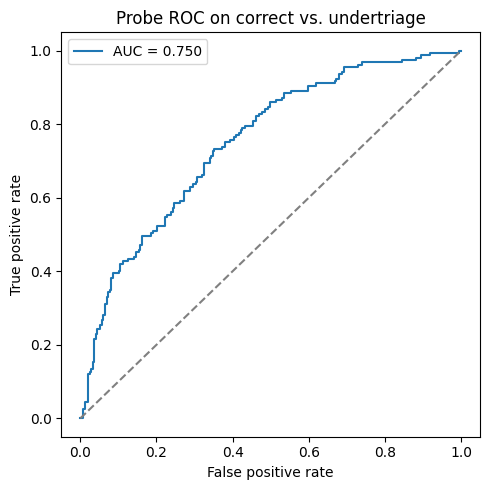


Per-condition AUC (leave-one-condition-out):
  zero_shot              AUC = 0.7340
  system_safety          AUC = 0.5212
  few_shot               AUC = 0.4910
  chain_of_thought       AUC = 0.6148


In [7]:
# binary classification probe
# correct = 0, undertriage = 1
# Overtriage and unparsed are excluded (undertriage is the main issue)

mask_probe = df["outcome"].isin(["correct", "undertriage"])
X_probe    = X[mask_probe]
y_probe    = (df.loc[mask_probe, "outcome"] == "undertriage").astype(int).values

print(f"Probe dataset: {mask_probe.sum()} samples  "
      f"({y_probe.sum()} undertriage, {(y_probe==0).sum()} correct)")

probe = LogisticRegression(max_iter=1000, C=1.0)
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# print out-of-fold predicted probabilities
y_prob = cross_val_predict(probe, X_probe, y_probe, cv=cv, method="predict_proba")[:, 1]
auc    = roc_auc_score(y_probe, y_prob)
print(f"\nProbe AUC (5-fold CV): {auc:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_probe, y_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Probe ROC on correct vs. undertriage")
plt.legend()
plt.tight_layout()
plt.savefig(results_dir / "probe_roc.png", dpi=150)
plt.show()

# per-condition AUC
print("\nPer-condition AUC (leave-one-condition-out):")
for test_cond in conditions:
    train_mask = mask_probe & (df["condition"] != test_cond)
    test_mask  = mask_probe & (df["condition"] == test_cond)

    X_tr = X[train_mask]
    y_tr = (df.loc[train_mask, "outcome"] == "undertriage").astype(int).values
    X_te = X[test_mask]
    y_te = (df.loc[test_mask, "outcome"] == "undertriage").astype(int).values

    if len(np.unique(y_te)) < 2:
        print(f"  {test_cond:<22}, only one class in test set")
        continue

    p = LogisticRegression(max_iter=1000, C=1.0)
    p.fit(X_tr, y_tr)
    probs = p.predict_proba(X_te)[:, 1]
    print(f"  {test_cond:<22} AUC = {roc_auc_score(y_te, probs):.4f}")

## Layer-wise probe

We created a layer-wise probe to test whether the layers we extracted were affecting our AUC metrics. If the AUC metrics vary a lot across the layers, that would indicate our layer choices weren't the best. In this case, our run produced a flat line graph, indicating that the layers seemed to not have an effect on the AUC (our layer choices were not bad).

layer 29: AUC = 0.7582
layer 30: AUC = 0.7594
layer 31: AUC = 0.7563
layer 32 (last): AUC = 0.7504


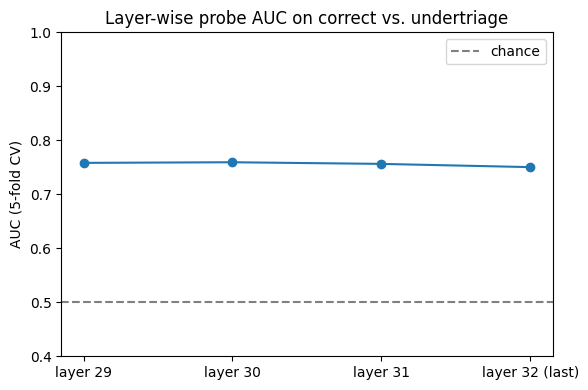

In [8]:
# Layer-wise probing
# Taking the last 4 layers (which is what we extracted)
# and then computing AUC for each captured layer
layer_labels = ["layer 29", "layer 30", "layer 31", "layer 32 (last)"]
layer_aucs   = []

for layer_idx in range(4):
    X_layer = np.stack([
        hs[f"{row.vignette_id}__{row.condition}"][layer_idx]
        for _, row in df.iterrows()
    ])
    X_layer = StandardScaler().fit_transform(X_layer)

    X_l = X_layer[mask_probe]
    y_l = y_probe

    p     = LogisticRegression(max_iter=1000, C=1.0)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    probs = cross_val_predict(p, X_l, y_l, cv=cv, method="predict_proba")[:, 1]
    auc   = roc_auc_score(y_l, probs)
    layer_aucs.append(auc)
    print(f"{layer_labels[layer_idx]}: AUC = {auc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(layer_labels, layer_aucs, marker="o")
plt.axhline(0.5, linestyle="--", color="gray", label="chance")
plt.ylim(0.4, 1.0)
plt.ylabel("AUC (5-fold CV)")
plt.title("Layer-wise probe AUC on correct vs. undertriage")
plt.legend()
plt.tight_layout()
plt.savefig(results_dir / "layerwise_auc.png", dpi=150)
plt.show()

## Nonlinear probe

Given that our previous probes did not work, we decided to try use non-linear probes like MLPs and kernel SVMs and seeing how those compared to our logistic regression baseline. Our results from this probe indicated that MLP and kernel SVMs were only marginally better than the logistic regression on 5-fold cross-validation.

In [9]:
# Nonlinear probes, specifically using MLP and kernel SVM.
# Compared against the logistic regression baseline.
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

X_probe_data = X[mask_probe]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

probes = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0),
    "MLP":                 MLPClassifier(hidden_layer_sizes=(256, 64), max_iter=500, random_state=42),
    "Kernel SVM (RBF / Gaussian)":    SVC(kernel="rbf", probability=True, random_state=42),
}

print("Nonlinear probe AUC (5-fold CV):")
for name, probe_model in probes.items():
    probs = cross_val_predict(probe_model, X_probe_data, y_probe,
                              cv=cv, method="predict_proba")[:, 1]
    auc = roc_auc_score(y_probe, probs)
    print(f"  {name:<25} AUC = {auc:.4f}")

Nonlinear probe AUC (5-fold CV):
  Logistic Regression       AUC = 0.7504
  MLP                       AUC = 0.7984
  Kernel SVM (RBF / Gaussian) AUC = 0.7756


## ESI-level analysis

We then decided to compute geometric analysis on the same basis of ESI cases. For each severity level, we took the hidden-state vectors, labeled them as correct or undertriage, and then computed a silhouette score for how well separated the correct and undertriage groups are in the hidden-state space.

We also probed the AUC for high-stakes analysis, focusing only on ESI 1 and ESI 2 cases and training a logistic regression probe on their hidden states using 5-fold cross-validation, and reported the AUC for classifying correct vs. undertriage. Surprisingly, this specific probe had an AUC of ~0.8502 compared to the overall probe AUC of ~0.75, so the probe actually performs better on the most critical cases.

In [10]:
# Per-ESI-level geometric analysis
print("Silhouette by gold ESI level (correct vs undertriage):\n")
for esi in [1, 2, 3, 4, 5]:
    mask_esi = mask_probe & (df["esi_gold_label"] == esi)
    if mask_esi.sum() < 4:
        continue
    X_e = X[mask_esi]
    y_e = (df.loc[mask_esi, "outcome"] == "undertriage").astype(int).values
    if len(np.unique(y_e)) < 2:
        print(f"ESI {esi}: only one class ({mask_esi.sum()} samples)")
        continue
    sil = silhouette_score(X_e, y_e)
    n_under = y_e.sum()
    print(f" ESI {esi}: silhouette={sil:.4f}  "
          f"({mask_esi.sum()} samples, {n_under} undertriage)")

# probe AUC for the most dangerous ESI cases (ESI 1 or 2)
print("\nProbe AUC for highly critical cases (gold ESI 1 or 2):")
mask_high = mask_probe & df["esi_gold_label"].isin([1, 2])
if mask_high.sum() >= 10:
    X_high = X[mask_high]
    y_high = (df.loc[mask_high, "outcome"] == "undertriage").astype(int).values
    if len(np.unique(y_high)) >= 2:
        cv_high = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        probs_high = cross_val_predict(
            LogisticRegression(max_iter=1000), X_high, y_high,
            cv=cv_high, method="predict_proba"
        )[:, 1]
        print(f"  AUC = {roc_auc_score(y_high, probs_high):.4f}  "
              f"(n={mask_high.sum()}, {y_high.sum()} undertriage)")

Silhouette by gold ESI level (correct vs undertriage):

 ESI 1: silhouette=0.1297  (88 samples, 49 undertriage)
 ESI 2: silhouette=0.1117  (149 samples, 70 undertriage)
 ESI 3: silhouette=0.1966  (119 samples, 36 undertriage)
 ESI 4: silhouette=0.1712  (34 samples, 2 undertriage)
ESI 5: only one class (14 samples)

Probe AUC for highly critical cases (gold ESI 1 or 2):
  AUC = 0.8502  (n=237, 119 undertriage)


## Mahalanobis Separation

We also decided to try some extra analysis by computing Mahalanobis Separation, which is a multivariate distance metric. We specifically did this between the centroid of correct prediction and the centroid of undertriage predictions, separately for each prompting condition.

Accounting for the covariance structure was a major reason behind why we used Mahalanobis. We added a ridge term of 1e-6 for numerical stability in our pooled covariance and computed the Mahalanobis distance, resulting in modest separations. CoT had the most noticeable margin difference and was the lowest, which may indicate that correct and undertriage cases look more alike in hidden-state space than under any other prompting condition.

In [11]:
# Mahalanobis separation
# Mahalanobis distance is a multivariate metric to determine how
# many standard deviations away a data point is from the mean of the mean
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

print("Mahalanobis distance between correct and undertriage centroids:\n")

# use PCA-reduced space (50 dims) for numerical stability
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X)

for cond in conditions:
    mask_c = df["condition"] == cond
    X_corr  = X_pca50[mask_c & (df["outcome"] == "correct")]
    X_under = X_pca50[mask_c & (df["outcome"] == "undertriage")]

    if len(X_corr) < 2 or len(X_under) < 2:
        continue

    # Pooled covariance (accounted)
    pooled_cov = np.cov(np.vstack([X_corr, X_under]).T) + np.eye(50) * 1e-6
    try:
        VI  = inv(pooled_cov)
        dist = mahalanobis(X_corr.mean(axis=0), X_under.mean(axis=0), VI)
        print(f"  {cond:<22} Mahalanobis distance = {dist:.4f}")
    except np.linalg.LinAlgError:
        print(f"  {cond:<22} singular covariance; skipped")

Mahalanobis distance between correct and undertriage centroids:

  zero_shot              Mahalanobis distance = 1.7310
  system_safety          Mahalanobis distance = 1.8942
  few_shot               Mahalanobis distance = 1.9127
  chain_of_thought       Mahalanobis distance = 1.4274


## Within-condition probe

Our within-condition probe tests whether hidden states can distinguish correct predictions from undertriage errors using only samples from a single prompting condition at a time. In this case, we trained and evaluated strictly within each condition to eliminate data leakage from other conditions.

For this method, we used logistic regression with 5-fold cross-validation to preserve class ratio across splits (because undertriage is a minor condition in most cases) and AUC as our metric for comparability across conditions.

In [12]:
# Within-condition probe
print("Within-condition probe AUC (5-fold CV, no cross-condition leakage):\n")

for cond in conditions:
    mask_wc = (df["condition"] == cond) & df["outcome"].isin(["correct", "undertriage"])
    X_wc    = X[mask_wc]
    y_wc    = (df.loc[mask_wc, "outcome"] == "undertriage").astype(int).values

    if len(np.unique(y_wc)) < 2:
        print(f"  {cond:<22} - only one class")
        continue
    if y_wc.sum() < 5:
        print(f"  {cond:<22} due to too few undertriage samples ({y_wc.sum()})")
        continue

    cv_wc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    probs_wc = cross_val_predict(
        LogisticRegression(max_iter=1000, C=1.0),
        X_wc, y_wc, cv=cv_wc, method="predict_proba"
    )[:, 1]
    auc_wc = roc_auc_score(y_wc, probs_wc)
    print(f"  {cond:<22} AUC = {auc_wc:.4f}  "
          f"(n={len(y_wc)}, {y_wc.sum()} undertriage)")

Within-condition probe AUC (5-fold CV, no cross-condition leakage):

  zero_shot              AUC = 0.8304  (n=102, 36 undertriage)
  system_safety          AUC = 0.8288  (n=79, 24 undertriage)
  few_shot               AUC = 0.6520  (n=104, 19 undertriage)
  chain_of_thought       AUC = 0.6273  (n=119, 78 undertriage)


## Integration analysis

Tests whether a combination of the best prompting strategy with geometric flagging can produce a lower undertriage error rate than either single layer on its own. The probe is trained on zero-shot hidden states and flags vignettes it predicts as undertriage risks. Flagged cases are escalated to few-shot, reserved for more geometrically tricky / risky cases.


In [13]:
# Dual-layer integration analysis
# THe probe is trained on zero_shot and escalates flagged cases to few_shot.
# Uses out-of-fold predictions to avoid in-sample bias.

# Score all zero_shot vignettes with the probe (out-of-fold)
mask_zs_all = df["condition"] == "zero_shot"
X_zs_all    = X[mask_zs_all]
df_zs       = df[mask_zs_all].copy().reset_index(drop=True)
y_zs_binary = (df_zs["outcome"] == "undertriage").astype(int).values

probe_zs  = LogisticRegression(max_iter=1000, C=1.0)
cv_zs     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
risk_oof  = cross_val_predict(probe_zs, X_zs_all, y_zs_binary,
                               cv=cv_zs, method="predict_proba")[:, 1]
df_zs["probe_risk"] = risk_oof
df_zs["probe_flag"] = (risk_oof >= 0.5).astype(int)

# Data joining with few_shot outcomes for same vignettes
df_fs = (df[df["condition"] == "few_shot"]
         [["vignette_id", "outcome", "predicted_esi"]]
         .rename(columns={"outcome": "fs_outcome",
                          "predicted_esi": "fs_predicted"}))

df_dual = df_zs.merge(df_fs, on="vignette_id")
n = len(df_dual)

# Dual-layer decision-making.
# If not flagged, then zero_shot output is kept, BUT...
# If flagged, then few_shot output instead.
df_dual["dual_outcome"] = np.where(
    df_dual["probe_flag"] == 1,
    df_dual["fs_outcome"],
    df_dual["outcome"]
)

# Print and report results.
zs_under   = (df_dual["outcome"]      == "undertriage").sum()
fs_under   = (df_dual["fs_outcome"]   == "undertriage").sum()
dual_under = (df_dual["dual_outcome"] == "undertriage").sum()
flagged    = df_dual["probe_flag"].sum()

true_under = df_dual["outcome"] == "undertriage"
probe_caught = (true_under & (df_dual["probe_flag"] == 1)).sum()
fs_fixed     = (true_under & (df_dual["probe_flag"] == 1) &
                (df_dual["fs_outcome"] != "undertriage")).sum()

print("===== Dual-layer integration analysis (n=150) =====\n")
print(f"Probe flagged as risky:     {flagged}/{n} ({100*flagged/n:.1f}%)\n")
print(f"Undertriage rates:")
print(f"  zero_shot alone:          {zs_under}/{n} ({100*zs_under/n:.1f}%)")
print(f"  few_shot alone:           {fs_under}/{n} ({100*fs_under/n:.1f}%)")
print(f"  dual-layer:               {dual_under}/{n} ({100*dual_under/n:.1f}%)\n")
print(f"Of {zs_under} true zero_shot undertriages:")
print(f"  probe flagged:            {probe_caught} ({100*probe_caught/zs_under:.1f}%)")
print(f"  probe missed:             {zs_under-probe_caught} ({100*(zs_under-probe_caught)/zs_under:.1f}%)")
print(f"  flagged + few_shot fixed: {fs_fixed} ({100*fs_fixed/zs_under:.1f}% of all undertriages resolved)")

# Threshold sensitivity results.
print("\n===== Threshold sensitivity =====")
print(f"{'threshold':>10} {'flagged':>8} {'dual undertriage':>18} {'probe recall':>14}")
true_under_arr = (df_dual["outcome"].values == "undertriage")
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    flag   = (df_dual["probe_risk"] >= thresh).values
    dual   = np.where(flag, df_dual["fs_outcome"].values, df_dual["outcome"].values)
    d_u    = (dual == "undertriage").sum()
    recall = (true_under_arr & flag).sum() / zs_under if zs_under > 0 else 0
    print(f"{thresh:>10.1f} {flag.sum():>8} {d_u:>10} ({100*d_u/n:4.1f}%)  {recall:>10.1%}")

===== Dual-layer integration analysis (n=150) =====

Probe flagged as risky:     31/150 (20.7%)

Undertriage rates:
  zero_shot alone:          36/150 (24.0%)
  few_shot alone:           19/150 (12.7%)
  dual-layer:               23/150 (15.3%)

Of 36 true zero_shot undertriages:
  probe flagged:            20 (55.6%)
  probe missed:             16 (44.4%)
  flagged + few_shot fixed: 15 (41.7% of all undertriages resolved)

===== Threshold sensitivity =====
 threshold  flagged   dual undertriage   probe recall
       0.3       35         20 (13.3%)       63.9%
       0.4       33         22 (14.7%)       58.3%
       0.5       31         23 (15.3%)       55.6%
       0.6       27         25 (16.7%)       50.0%
       0.7       26         26 (17.3%)       47.2%
